# 3. Topic Modeling sur les Avis d'Assurance

LDA (Latent Dirichlet Allocation) pour identifier ~6 topics dans les reviews.

**Topics attendus :** Pricing, Coverage, Enrollment, Customer Service, Claims Processing, Cancellation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

BASE_DIR = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print(f"✅ Gensim {gensim.__version__}")

✅ Gensim 4.4.0


## 3.1 Chargement des données nettoyées

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'reviews_clean.csv')
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")

text_col = 'review_clean' if 'review_clean' in df.columns else 'review'
print(f"\nColonne utilisée : {text_col}")
print(f"\nExemple :\n{df[text_col].iloc[0]}")

Shape : (23516, 10)
Colonnes : ['stars', 'insurer', 'date', 'product', 'review_fr', 'review', 'review_clean', 'review_length', 'word_count', 'language']

Colonne utilisée : review_clean

Exemple :
person phone clear friendly explained everything would recommend insurance without hesitation thank person contacted


## 3.2 Préparation du corpus pour LDA

In [3]:
# Stopwords étendus
stop_words = set(stopwords.words('english'))
stop_words.update(STOPWORDS)
stop_words.update(['insurance', 'company', 'policy', 'insur', 'would', 'get',
                   'also', 'one', 'us', 'really', 'even', 'still', 'like', 'just'])

def tokenize_for_lda(text):
    if pd.isna(text):
        return []
    tokens = simple_preprocess(str(text), deacc=True)
    return [t for t in tokens if t not in stop_words and len(t) > 3]

print("Tokenisation...")
texts = df[text_col].apply(tokenize_for_lda).tolist()
all_words = [w for doc in texts for w in doc]
print(f"Tokens totaux       : {len(all_words)}")
print(f"Vocabulaire unique  : {len(set(all_words))}")
print(f"Tokens moy/document : {len(all_words)/len(texts):.1f}")
print(f"\nTop 20 mots :")
print(Counter(all_words).most_common(20))

Tokenisation...
Tokens totaux       : 499211
Vocabulaire unique  : 17568
Tokens moy/document : 21.2

Top 20 mots :
[('service', 6643), ('satisfied', 5874), ('contract', 4978), ('price', 4801), ('years', 4078), ('good', 3821), ('customer', 3559), ('prices', 3358), ('vehicle', 2884), ('time', 2869), ('recommend', 2815), ('phone', 2781), ('months', 2703), ('year', 2662), ('file', 2378), ('thank', 2362), ('mutual', 2304), ('home', 2100), ('euros', 1929), ('insurer', 1901)]


In [4]:
dictionary = corpora.Dictionary(texts)
print(f"Dictionnaire avant filtrage : {len(dictionary)} mots")

dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionnaire après filtrage : {len(dictionary)} mots")

corpus_bow = [dictionary.doc2bow(text) for text in texts]
print(f"Corpus : {len(corpus_bow)} documents")

# Exemple
print(f"\nDocument 0 (5 premiers) :")
print([(dictionary[id_], freq) for id_, freq in corpus_bow[0][:5]])

Dictionnaire avant filtrage : 17568 mots
Dictionnaire après filtrage : 5629 mots
Corpus : 23516 documents

Document 0 (5 premiers) :
[('clear', 1), ('contacted', 1), ('explained', 1), ('friendly', 1), ('hesitation', 1)]


## 3.3 Entraînement du modèle LDA

In [5]:
NUM_TOPICS = 6

print(f"Entraînement LDA (num_topics={NUM_TOPICS})...")
print("Patience... (quelques minutes)")

lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    iterations=400,
    alpha='auto',
    eta='auto',
    per_word_topics=True,
)

print("\n✅ Entraînement terminé !\n")
print("=== Top 10 mots par topic ===")
for i, topic in lda_model.print_topics(num_topics=NUM_TOPICS, num_words=10):
    print(f"\n  Topic {i}: {topic}")

Entraînement LDA (num_topics=6)...
Patience... (quelques minutes)

✅ Entraînement terminé !

=== Top 10 mots par topic ===

  Topic 0: 0.029*"contract" + 0.023*"mutual" + 0.017*"email" + 0.014*"phone" + 0.013*"documents" + 0.012*"sent" + 0.012*"send" + 0.011*"received" + 0.011*"termination" + 0.010*"customer"

  Topic 1: 0.068*"year" + 0.034*"years" + 0.032*"euros" + 0.025*"increase" + 0.019*"contract" + 0.017*"bonus" + 0.013*"monthly" + 0.012*"subscription" + 0.012*"contracts" + 0.010*"expensive"

  Topic 2: 0.052*"satisfied" + 0.050*"service" + 0.040*"price" + 0.031*"good" + 0.029*"prices" + 0.025*"recommend" + 0.019*"thank" + 0.017*"customer" + 0.015*"simple" + 0.015*"fast"

  Topic 3: 0.028*"vehicle" + 0.027*"years" + 0.016*"accident" + 0.015*"expert" + 0.014*"home" + 0.014*"disaster" + 0.013*"insured" + 0.012*"responsible" + 0.012*"claim" + 0.010*"maif"

  Topic 4: 0.024*"file" + 0.018*"months" + 0.011*"time" + 0.010*"work" + 0.008*"month" + 0.007*"life" + 0.006*"flee" + 0.006*"ca

## 3.4 Identification des topics

In [6]:
# Mapping topics → labels basé sur les mots dominants
# À AJUSTER selon les résultats réels du modèle !
TOPIC_LABELS = {
    0: 'Pricing & Cost',
    1: 'Coverage & Benefits',
    2: 'Enrollment Process',
    3: 'Customer Service',
    4: 'Claims Processing',
    5: 'Cancellation',
}

print("=== Analyse des topics ===\n")
for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ', '.join([f"{w}({s:.3f})" for w, s in words])
    print(f"Topic {topic_id} → {TOPIC_LABELS[topic_id]}")
    print(f"  {word_str}\n")

=== Analyse des topics ===

Topic 0 → Pricing & Cost
  contract(0.029), mutual(0.023), email(0.017), phone(0.014), documents(0.013), sent(0.012), send(0.012), received(0.011), termination(0.011), customer(0.010)

Topic 1 → Coverage & Benefits
  year(0.068), years(0.034), euros(0.032), increase(0.025), contract(0.019), bonus(0.017), monthly(0.013), subscription(0.012), contracts(0.012), expensive(0.010)

Topic 2 → Enrollment Process
  satisfied(0.052), service(0.050), price(0.040), good(0.031), prices(0.029), recommend(0.025), thank(0.019), customer(0.017), simple(0.015), fast(0.015)

Topic 3 → Customer Service
  vehicle(0.028), years(0.027), accident(0.016), expert(0.015), home(0.014), disaster(0.014), insured(0.013), responsible(0.012), claim(0.012), maif(0.010)

Topic 4 → Claims Processing
  file(0.024), months(0.018), time(0.011), work(0.010), month(0.008), life(0.007), flee(0.006), care(0.006), told(0.006), people(0.005)

Topic 5 → Cancellation
  phone(0.028), advisor(0.019), perso

## 3.5 Cohérence du modèle

In [7]:
coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
cv_score = coherence_model.get_coherence()
print(f"Score de cohérence C_V : {cv_score:.4f}")
print("(> 0.5 = bon, > 0.65 = très bon)")

Score de cohérence C_V : 0.5556
(> 0.5 = bon, > 0.65 = très bon)


Recherche du nombre optimal de topics (2-12)...
  n=2: C_V=0.4497
  n=4: C_V=0.5188
  n=6: C_V=0.5244
  n=8: C_V=0.5486
  n=10: C_V=0.5273
  n=12: C_V=0.5026


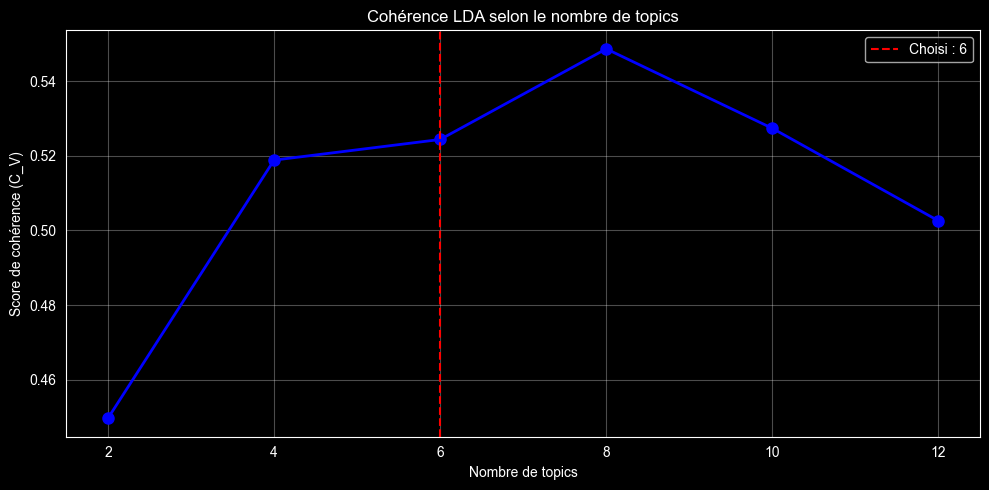


Optimal suggéré : 8 topics (C_V=0.5486)


In [8]:
print("Recherche du nombre optimal de topics (2-12)...")
coherence_values = []
n_range = list(range(2, 13, 2))

for n in n_range:
    m = LdaModel(corpus=corpus_bow, id2word=dictionary,
                 num_topics=n, random_state=42, passes=5, iterations=100)
    cm = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence='c_v')
    coh = cm.get_coherence()
    coherence_values.append(coh)
    print(f"  n={n}: C_V={coh:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_range, coherence_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=NUM_TOPICS, color='r', linestyle='--', label=f'Choisi : {NUM_TOPICS}')
plt.xlabel('Nombre de topics')
plt.ylabel('Score de cohérence (C_V)')
plt.title('Cohérence LDA selon le nombre de topics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'lda_coherence.png', dpi=100)
plt.show()

optimal = n_range[np.argmax(coherence_values)]
print(f"\nOptimal suggéré : {optimal} topics (C_V={max(coherence_values):.4f})")

## 3.6 Visualisation pyLDAvis

In [17]:
try:
    import pyLDAvis
    import pyLDAvis.gensim_models

    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim_models.prepare(lda_model, corpus_bow, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, str(MODELS_DIR / 'lda_visualization.html'))
    print(f"✅ Sauvegardé : {MODELS_DIR / 'lda_visualization.html'}")
    pyLDAvis.display(vis)
except ImportError:
    print("⚠️ pyLDAvis non disponible. pip install pyldavis")
except Exception as e:
    print(f"Erreur pyLDAvis : {e}")

✅ Sauvegardé : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/lda_visualization.html


## 3.7 Attribution des topics aux reviews

In [18]:
def get_dominant_topic(bow):
    probs = lda_model.get_document_topics(bow)
    if not probs:
        return 0, 0.0
    top = max(probs, key=lambda x: x[1])
    return top[0], float(top[1])

print("Attribution des topics...")
assignments = [get_dominant_topic(bow) for bow in corpus_bow]
df['topic_id'] = [a[0] for a in assignments]
df['topic_prob'] = [a[1] for a in assignments]
df['topic_label'] = df['topic_id'].map(TOPIC_LABELS)

print("\nDistribution des topics :")
print(df['topic_label'].value_counts())

Attribution des topics...

Distribution des topics :
topic_label
Enrollment Process     10159
Pricing & Cost          3963
Customer Service        3962
Claims Processing       3166
Coverage & Benefits     1184
Cancellation            1082
Name: count, dtype: int64


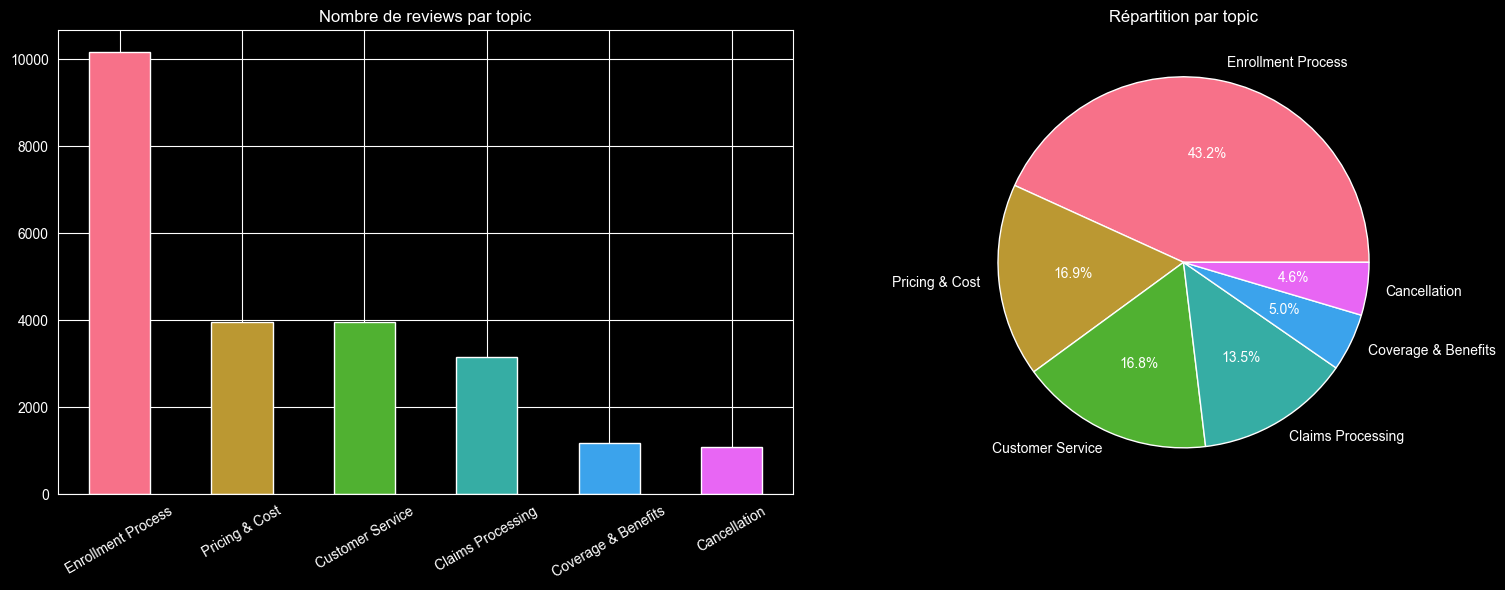

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('husl', NUM_TOPICS)

topic_counts = df['topic_label'].value_counts()
topic_counts.plot(kind='bar', ax=axes[0], color=palette)
axes[0].set_title('Nombre de reviews par topic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%', colors=palette)
axes[1].set_title('Répartition par topic')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'topic_distribution.png', dpi=100)
plt.show()

In [20]:
text_display = 'review' if 'review' in df.columns else text_col
print("=== Exemples de reviews par topic ===")
for tid, label in TOPIC_LABELS.items():
    reviews = df[df['topic_id'] == tid][text_display].dropna()
    print(f"\n{'='*55}")
    print(f"Topic {tid}: {label}  ({len(reviews)} reviews)")
    print('='*55)
    for i, r in enumerate(reviews.head(2), 1):
        print(f"  [{i}] {str(r)[:200]}...")

=== Exemples de reviews par topic ===

Topic 0: Pricing & Cost  (3963 reviews)
  [1] Hello, currently I am at Active Insurance under the number 164900 and for almost a year my new insurance has been trying to terminate with the Hamon laws without success each time it is missing a truc...
  [2]  My mother has died for several months and still no reversion (missing piece ... My sister received her share 2 days ago and the files were sent in the same mail - look for the error)...

Topic 1: Coverage & Benefits  (1184 reviews)
  [1] The year of my subscription I got a good price being a good 50 % for 2 years.
My big surprise the following year was to see my premium increased by more than 8% when I had no claim and the confinement...
  [2] Hello,
I have just made a change of contract holder on a contract of less than 30 days,
This leads to its termination and a new subscription and I am refused the 20% reduction (family offer 50% bonus)...

Topic 2: Enrollment Process  (10159 reviews)
  [1] 

## 3.8 Analyse croisée topics × étoiles

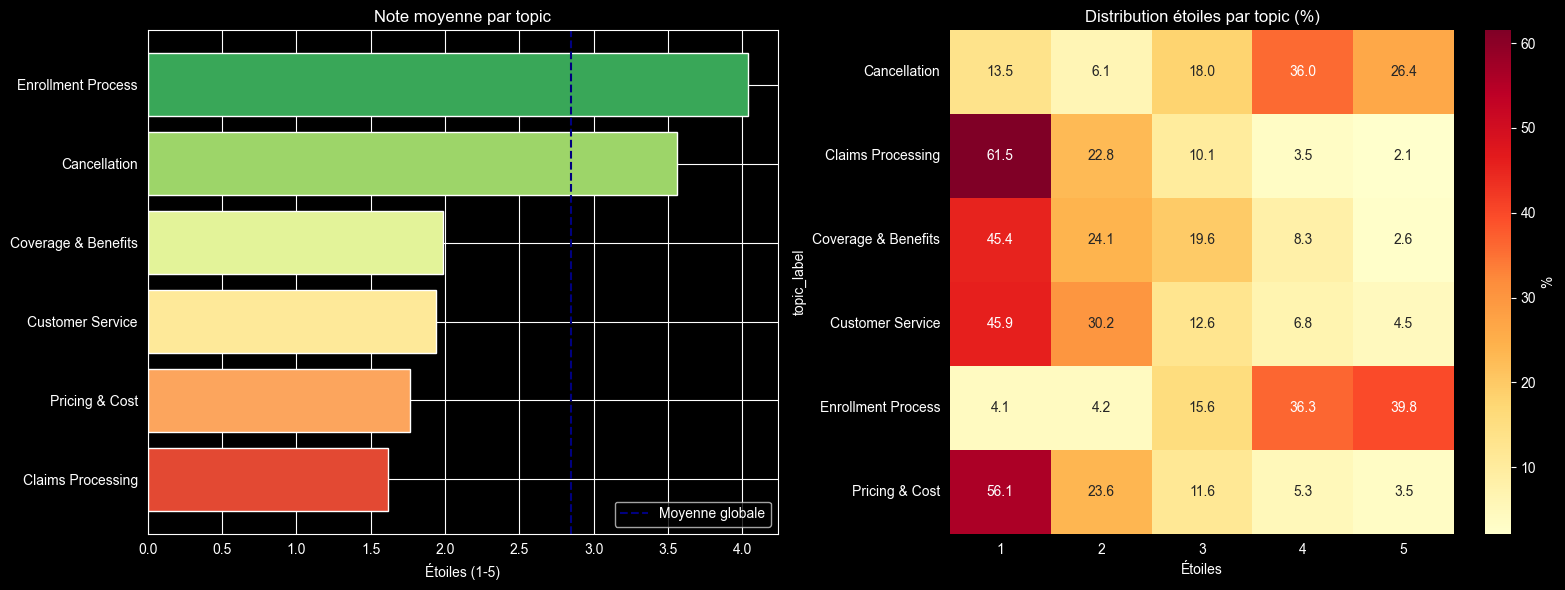

In [21]:
if 'stars' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    avg_stars = df.groupby('topic_label')['stars'].mean().sort_values()
    colors = sns.color_palette('RdYlGn', len(avg_stars))
    axes[0].barh(avg_stars.index, avg_stars.values, color=colors)
    axes[0].axvline(df['stars'].mean(), color='navy', linestyle='--', label='Moyenne globale')
    axes[0].set_title('Note moyenne par topic')
    axes[0].set_xlabel('Étoiles (1-5)')
    axes[0].legend()

    pivot = df.groupby(['topic_label', 'stars']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
                cbar_kws={'label': '%'})
    axes[1].set_title('Distribution étoiles par topic (%)')
    axes[1].set_xlabel('Étoiles')

    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'topic_stars_heatmap.png', dpi=100)
    plt.show()
else:
    print("Colonne 'stars' non disponible")

## 3.9 Sauvegarde

In [22]:
# Sauvegarder modèle et dictionnaire
lda_model.save(str(MODELS_DIR / 'lda_model'))
dictionary.save(str(MODELS_DIR / 'lda_dictionary'))
print(f"✅ Modèle LDA    : {MODELS_DIR / 'lda_model'}")

# Sauvegarder dataset enrichi
out_path = DATA_PROCESSED / 'reviews_topics.csv'
df.to_csv(out_path, index=False)
print(f"✅ Dataset topics : {out_path}")
print(f"   Shape  : {df.shape}")
print(f"   Colonnes ajoutées : topic_id, topic_prob, topic_label")
df[['topic_id', 'topic_label', 'topic_prob']].head(5)

✅ Modèle LDA    : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/lda_model
✅ Dataset topics : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/data/processed/reviews_topics.csv
   Shape  : (23516, 13)
   Colonnes ajoutées : topic_id, topic_prob, topic_label


,topic_id,topic_label,topic_prob
0,5,Cancellation,0.474494
1,2,Enrollment Process,0.875752
2,3,Customer Service,0.523039
3,3,Customer Service,0.433852
4,2,Enrollment Process,0.594643


## 3.10 Analyse de la distribution des probabilités de topic

On examine ici la distribution des probabilités d'appartenance au topic dominant pour chaque document.
Un score élevé indique que le document est fortement associé à un seul topic (thème clair),
tandis qu'un score faible indique un document ambigu appartenant à plusieurs topics à la fois.

On analyse également les documents dits "mixtes" — ceux dont la probabilité du topic dominant
est inférieure à 0.4 — pour comprendre s'ils forment des thèmes de transition ou simplement
des avis généralistes.

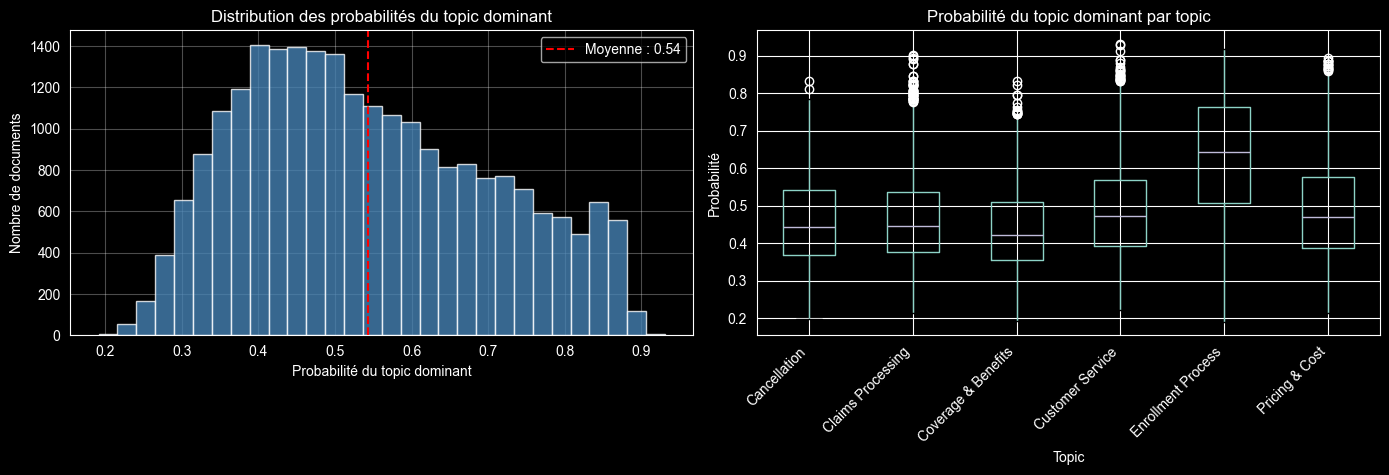


Documents ambigus (topic_prob < 0.4) : 5113 (21.7%)
Documents clairement assignés (topic_prob >= 0.4) : 18403 (78.3%)

Stats sur topic_prob :
count    23516.0000
mean         0.5431
std          0.1612
min          0.1912
25%          0.4138
50%          0.5204
75%          0.6647
max          0.9309
Name: topic_prob, dtype: float64


In [23]:
# Distribution des probabilités du topic dominant
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global de topic_prob
axes[0].hist(df['topic_prob'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=df['topic_prob'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {df['topic_prob'].mean():.2f}")
axes[0].set_title('Distribution des probabilités du topic dominant')
axes[0].set_xlabel('Probabilité du topic dominant')
axes[0].set_ylabel('Nombre de documents')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot par topic
df.boxplot(column='topic_prob', by='topic_label', ax=axes[1])
axes[1].set_title('Probabilité du topic dominant par topic')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Probabilité')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'topic_prob_distribution.png', dpi=100)
plt.show()

# Documents "mixtes" (faible certitude d'appartenance à un topic)
threshold = 0.4
mixed_docs = df[df['topic_prob'] < threshold]
print(f"\nDocuments ambigus (topic_prob < {threshold}) : {len(mixed_docs)} ({len(mixed_docs)/len(df)*100:.1f}%)")
print(f"Documents clairement assignés (topic_prob >= {threshold}) : {len(df) - len(mixed_docs)} ({(len(df)-len(mixed_docs))/len(df)*100:.1f}%)")

print(f"\nStats sur topic_prob :")
print(df['topic_prob'].describe().round(4))